In [118]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

In [119]:
load_dotenv()
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
database = os.getenv('DB_NAME')

In [120]:
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"
engine = create_engine(connection_string)

In [115]:
query = """
SELECT 
    dt.month_name, 
    dt.month_number, 
    SUM(ft.amount_usd) AS total_value, 
    COUNT(ft.transaction_id) AS total_volume
FROM fact_transactions ft  
INNER JOIN dim_date dt ON ft.date_key = dt.date_key
GROUP BY dt.month_name, dt.month_number
ORDER BY total_value DESC;
"""

df = pd.read_sql(query, con=engine)

In [64]:
df.to_csv('data/monthly_transaction_report.csv', index=False)

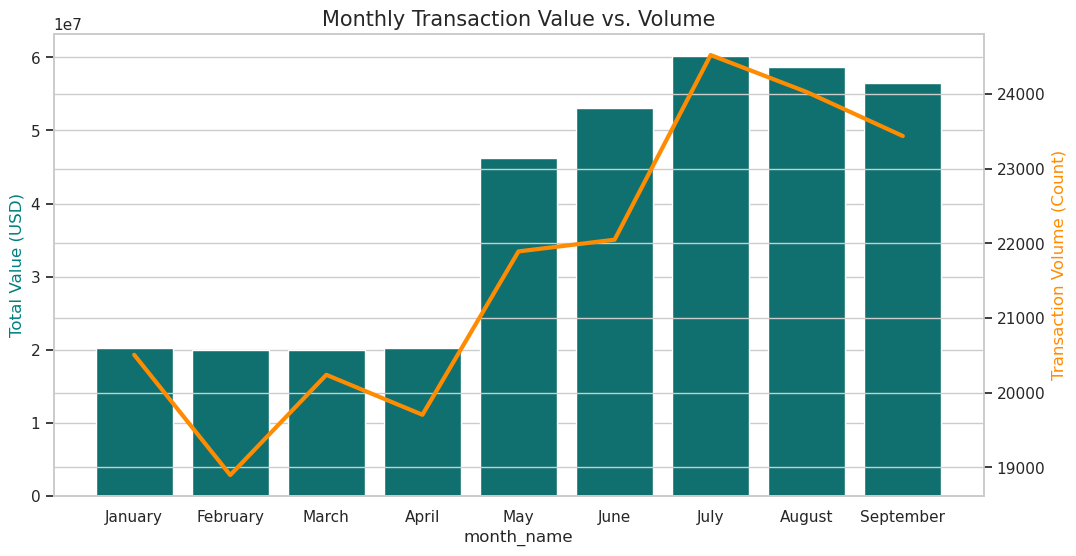

In [65]:
# ensure that the date is sorted
df = df.sort_values('month_number')

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=df, x='month_name', y='total_value', ax=ax1, color='teal')
ax1.set_ylabel('Total Value (USD)', fontsize=12, color='teal')

ax2 = ax1.twinx()
sns.lineplot(data=df, x="month_name", y="total_volume", markers="o", ax=ax2, color="darkorange", linewidth=3)
ax2.set_ylabel('Transaction Volume (Count)', fontsize=12, color='darkorange')

plt.title('Monthly Transaction Value vs. Volume', fontsize=15)
plt.show()

In [69]:
query = """
SELECT 
    dl.country as country,  
    dl.region as re, 
    AVG(ft.amount_usd) AS average_value, 
    COUNT(ft.transaction_id) AS total_volume
FROM fact_transactions ft  
INNER JOIN dim_location dl ON ft.location_key = dl.location_key
GROUP BY dl.country, dl.region
ORDER BY average_value DESC
LIMIT 10;
"""

df = pd.read_sql(query, con=engine)

In [70]:
df.to_csv('data/regional_transaction.csv', index=False)

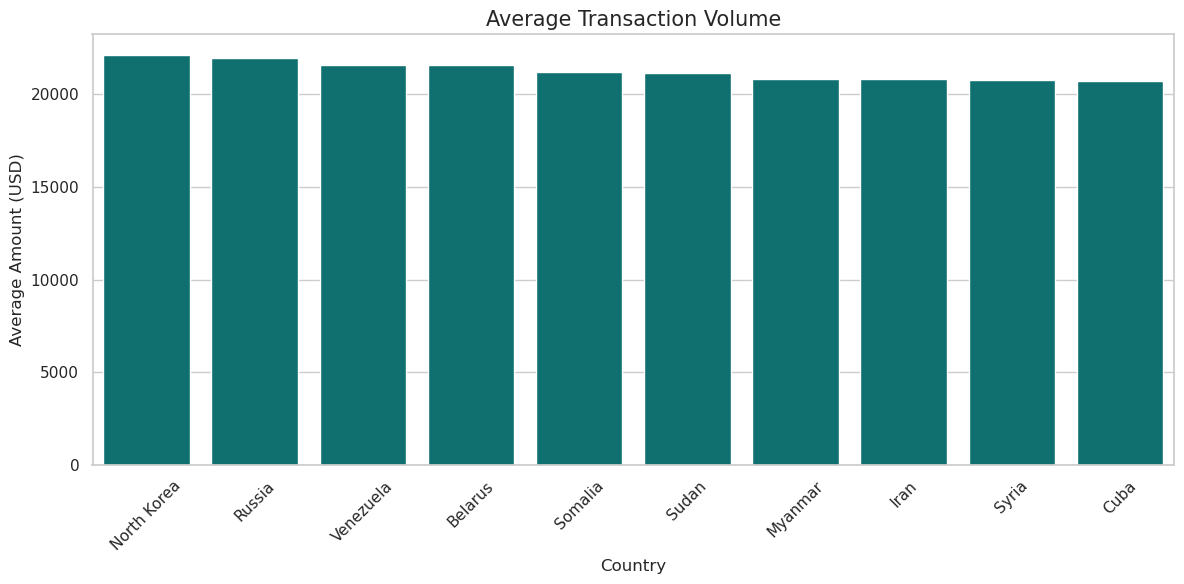

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df, x='country', y='average_value', color='teal')
          
plt.title('Average Transaction Volume', fontsize=15)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average Amount (USD)', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [72]:
query = """
SELECT
  sum(amount_usd) as total, 
  channel 
FROM fact_transactions ft  
GROUP BY channel
ORDER BY total DESC;
"""
chanel_transaction_volume = pd.read_sql(query, con=engine)


In [73]:
chanel_transaction_volume.to_csv('data/transaction_volume_per_channel.csv', index=False)

In [74]:
query = """
SELECT
  sum(amount_usd) as total, 
  transaction_type 
FROM fact_transactions ft  
GROUP BY transaction_type
ORDER BY total DESC;
"""
transaction_type_volume = pd.read_sql(query, con=engine)

In [75]:
transaction_type_volume.to_csv('data/transaction_type_volume.csv', index=False)

In [76]:
query = """
SELECT 
    dm.merchant_category, 
    SUM(ft.amount_usd) AS total_spend, 
    COUNT(ft.transaction_id) AS total_volume
FROM fact_transactions ft  
INNER JOIN dim_merchant dm ON ft.merchant_key = dm.merchant_key
GROUP BY dm.merchant_category
ORDER BY total_spend DESC;
"""

transactions_by_merchant_category = pd.read_sql(query, con=engine)

In [77]:
transactions_by_merchant_category.to_csv('data/transactions_by_merchant_category.csv', index=False)

In [79]:
fraud_query = """
WITH  transaction_history AS (
  SELECT
    customer_key,
    transaction_datetime,
    amount_usd,
    channel,
    AVG(amount_usd) OVER(PARTITION BY channel) as avg_val,
    STDDEV(amount_usd) OVER(PARTITION BY channel) as std_val,
    LAG(transaction_datetime) OVER (PARTITION BY customer_key ORDER BY transaction_datetime) as prev_time,
    LAG(amount_usd, 1, 0) OVER (PARTITION BY customer_key ORDER BY transaction_datetime) as prev_amount
  FROM fact_transactions
)

SELECT 
  *,
  TIMESTAMPDIFF(MINUTE, prev_time, transaction_datetime) AS minutes_between
FROM transaction_history
WHERE 
  prev_time IS NOT NULL
  AND TIMESTAMPDIFF(MINUTE, prev_time, transaction_datetime) <= 10 
  AND amount_usd > (avg_val + (3 * std_val))
ORDER BY minutes_between ASC;
"""
df = pd.read_sql(fraud_query, engine)
df.to_csv('data/Live_Fraud_Alerts.csv', index=False)
print("Fraud report updated!")

Fraud report updated!


In [80]:
query = """
WITH  transaction_history AS (
  SELECT
    customer_key,
    transaction_datetime,
    amount_usd,
    LAG(transaction_datetime) OVER (PARTITION BY customer_key ORDER BY transaction_datetime) as prev_time
  FROM fact_transactions
), 
flagged_bursts AS (
  SELECT
    customer_key,
    amount_usd,
    TIMESTAMPDIFF(MINUTE, prev_time, transaction_datetime) AS time_gap
  FROM transaction_history
  WHERE prev_time IS NOT NULL 
  AND TIMESTAMPDIFF(MINUTE, prev_time, transaction_datetime) <= 10
)
SELECT 
  customer_key,
  COUNT(*) AS total_burst_attempts,
  SUM(amount_usd) AS total_risk_value,
  AVG(amount_usd) AS avg_burst_amount
FROM flagged_bursts
GROUP BY customer_key
ORDER BY total_burst_attempts DESC, total_risk_value DESC;
"""
df = pd.read_sql(query, engine)

df.to_csv('data/fraud_summary.csv', index=False)
print("Dashboard data updated!")

Dashboard data updated!


In [81]:
query = """
WITH  transaction_history AS (
  SELECT
    customer_key,
    transaction_datetime,
    amount_usd,
    AVG(amount_usd) OVER(PARTITION BY channel) as avg_val,
    STDDEV(amount_usd) OVER(PARTITION BY channel) as std_val,
    LAG(transaction_datetime) OVER (PARTITION BY customer_key ORDER BY transaction_datetime) as prev_time
  FROM fact_transactions
), 
flagged_bursts AS (
  SELECT
    customer_key,
    amount_usd,
    TIMESTAMPDIFF(MINUTE, prev_time, transaction_datetime) AS time_gap
  FROM transaction_history
  WHERE prev_time IS NOT NULL 
  AND TIMESTAMPDIFF(MINUTE, prev_time, transaction_datetime) <= 10
  AND amount_usd > (avg_val + (3 * std_val))
)
SELECT 
  fb.customer_key,
  dc.full_name,
  COUNT(*) AS total_burst_attempts,
  SUM(amount_usd) AS total_risk_value,
  AVG(amount_usd) AS avg_burst_amount
FROM flagged_bursts fb
LEFT JOIN dim_customer dc ON fb.customer_key = dc.customer_key
GROUP BY customer_key
ORDER BY total_burst_attempts DESC, total_risk_value DESC;
"""
df = pd.read_sql(query, engine)

df.to_csv('data/fraud_suspects_summary.csv', index=False)
print("updated!")

updated!


In [82]:
query = """
SELECT
  channel,
  COUNT(transaction_id) as total_transactions,
  SUM(amount_usd) as total_transaction_value,
  transaction_hour
FROM fact_transactions
WHERE transaction_hour  >= 1 AND transaction_hour < 4
GROUP BY channel, transaction_hour
ORDER BY total_transactions DESC, total_transaction_value DESC;
"""
df = pd.read_sql(query, engine)
df.to_csv('data/off_hours_activity.csv', index=False)
print("data updated!")

data updated!


In [83]:
query = """
SELECT *
FROM (
  SELECT 
    transaction_id,
    amount_usd,
    channel,
    AVG(amount_usd) OVER(PARTITION BY channel) as avg_val,
    STDDEV(amount_usd) OVER(PARTITION BY channel) as std_val
FROM fact_transactions
) AS stats
  
WHERE amount_usd > (avg_val + (3 * std_val))
ORDER BY amount_usd DESC;
"""
df = pd.read_sql(query, engine)
df.to_csv('data/statistical_outliers_transactions.csv', index=False)
print("data updated!")

data updated!


In [116]:
query = """
SELECT * FROM suspicious_transactions_view;
"""
df = pd.read_sql(query, engine)
df.to_csv('data/suspicious_transactions.csv', index=False)
df.head()

,transaction_id,amount_usd,registered_country,transaction_country,is_offhours_flag,is_geomismatch_flag,is_outlier_flag,is_velocity_flag,total_flag_count
0,TXN000190791,45159.53,Ghana,South Africa,1,1,1,1,4
1,TXN000191499,29027.53,Ghana,Venezuela,1,1,1,1,4
2,TXN000191256,27501.47,Ghana,North Korea,1,1,1,1,4
3,TXN000193733,25238.47,Nigeria,Russia,1,1,1,1,4
4,TXN000189643,17742.32,South Africa,Germany,1,1,1,1,4


In [85]:
query = """
WITH
  channel_counts AS (
    SELECT
      customer_key,
      channel,
      COUNT(*) as cnt
  FROM fact_transactions 
  GROUP BY customer_key, channel
),
channel_winner AS (
  SELECT customer_key, channel,
         ROW_NUMBER() OVER(PARTITION BY customer_key ORDER BY cnt DESC) as rn
  FROM channel_counts
),
merchant_counts AS (
  SELECT ft.customer_key, dm.merchant_category, COUNT(*) as cnt
  FROM fact_transactions ft
  JOIN dim_merchant dm ON ft.merchant_key = dm.merchant_key
  GROUP BY ft.customer_key, dm.merchant_category
),
merchant_winner AS (
  SELECT customer_key, merchant_category,
         ROW_NUMBER() OVER(PARTITION BY customer_key ORDER BY cnt DESC) as rn
  FROM merchant_counts
),
hour_counts AS (
  SELECT customer_key, transaction_hour, COUNT(*) as cnt
  FROM fact_transactions
  GROUP BY customer_key, transaction_hour
),
hour_winner AS (
  SELECT customer_key, transaction_hour,
         ROW_NUMBER() OVER(PARTITION BY customer_key ORDER BY cnt DESC) as rn
  FROM hour_counts
)
  
SELECT
  ft.customer_key,
  dc.full_name,
  COUNT(ft.transaction_id) AS total_transactions,
  SUM(ft.amount_usd) AS total_spend,
  AVG(ft.amount_usd) AS avg_transaction_value,
  cw.channel AS most_common_channel,
  mw.merchant_category AS most_common_category,
  hw.transaction_hour AS most_common_transaction_hour
FROM fact_transactions ft
LEFT JOIN dim_customer dc ON ft.customer_key = dc.customer_key
LEFT JOIN channel_winner cw ON ft.customer_key = cw.customer_key AND cw.rn = 1
LEFT JOIN merchant_winner mw ON ft.customer_key = mw.customer_key AND mw.rn = 1
LEFT JOIN hour_winner hw ON ft.customer_key = hw.customer_key AND hw.rn = 1
GROUP BY  ft.customer_key, cw.channel, mw.merchant_category, hw.transaction_hour;
"""

df = pd.read_sql(query, engine)
df.to_csv('data/customer_transaction_baseline.csv', index=False)
print("data updated!")

data updated!


In [86]:
query = """
WITH customer_spend  AS (
  SELECT 
  dc.customer_key,
  dc.full_name,
  ft.amount_usd,
  AVG(ft.amount_usd) OVER(PARTITION BY dc.customer_key) as avg_spend,
  STDDEV(ft.amount_usd) OVER(PARTITION BY dc.customer_key) as std_spend
FROM fact_transactions ft
LEFT JOIN dim_customer dc ON ft.customer_key = dc.customer_key
)
SELECT *
FROM customer_spend
WHERE amount_usd > (avg_spend + (3 * std_spend));
"""

df = pd.read_sql(query, engine)
df.to_csv('data/customer_baseline_deviation.csv', index=False)
print("data updated!")

data updated!


In [87]:
query = """
WITH customer_fraud_flag  AS (
  SELECT 
  ft.customer_key, 
  dc.full_name as customer_name, 
  COUNT(*) AS total_fraud_flags, 
  RANK() OVER(ORDER BY COUNT(*) DESC) AS fraud_risk_rank
FROM suspicious_transactions_view stv
LEFT JOIN fact_transactions ft ON stv.transaction_id = ft.transaction_id
LEFT JOIN dim_customer dc ON ft.customer_key = dc.customer_key
WHERE total_flag_count >= 3 
GROUP BY ft.customer_key, dc.full_name
)
SELECT 
  *,
  CASE
      WHEN fraud_risk_rank < 10 THEN 'High Risk'
      WHEN fraud_risk_rank BETWEEN 10 AND 15 THEN 'Medium Risk'
      ELSE 'Low Risk'
  END AS risk_group
FROM customer_fraud_flag
WHERE fraud_risk_rank <= 20;
"""

df = pd.read_sql(query, engine)
df.to_csv('data/risky_customers.csv', index=False)
print("data updated!")

data updated!


In [88]:
query = """
WITH merchant_risk_stats AS (
 SELECT 
    dm.merchant_category,
    dm.merchant_key,
    COUNT(ft.transaction_id) as total_transaction_count,
    COUNT(CASE WHEN ft.is_flagged = 1 THEN  1 END) AS flagged_total_transaction_count,
    SUM(CASE WHEN ft.is_flagged = 1 THEN ft.amount_usd ELSE 0 END) AS flagged_total_transactions_value
  FROM fact_transactions ft
  LEFT JOIN dim_merchant dm ON ft.merchant_key = dm.merchant_key  
  GROUP BY dm.merchant_category, dm.merchant_key
)
SELECT 
    *,
    (CAST(flagged_total_transaction_count AS DECIMAL) / NULLIF(total_transaction_count, 0)) * 100 as flagged_percentage,
    RANK() OVER(ORDER BY (CAST(flagged_total_transaction_count AS DECIMAL) / NULLIF(total_transaction_count, 0)) DESC) AS risk_rnk
FROM merchant_risk_stats;
"""

df = pd.read_sql(query, engine)
df.to_csv('data/merchant_risk_scoring.csv', index=False)
print("data updated!")

data updated!


In [89]:
query = """
WITH channel_risk_stats AS (
 SELECT 
    ft.channel,
    COUNT(ft.transaction_id) as total_transaction_count,
    COUNT(CASE WHEN ft.is_flagged = 1 THEN  1 END) AS flagged_total_transaction_count,
    SUM(CASE WHEN ft.is_flagged = 1 THEN ft.amount_usd ELSE 0 END) AS flagged_total_transactions_value
  FROM fact_transactions ft
  GROUP BY ft.channel
)
SELECT 
    *,
    (CAST(flagged_total_transaction_count AS DECIMAL) / NULLIF(total_transaction_count, 0)) * 100 as flagged_percentage,
    RANK() OVER(ORDER BY (CAST(flagged_total_transaction_count AS DECIMAL) / NULLIF(total_transaction_count, 0)) DESC) AS risk_rnk
FROM channel_risk_stats;
"""

df = pd.read_sql(query, engine)
df.to_csv('data/channel_risk_scoring.csv', index=False)
print("data updated!")

data updated!


In [90]:
query = """
WITH channel_hour_stats AS (
 SELECT 
    ft.channel,
    COUNT(ft.transaction_id) as total_transaction_count,
    ft.transaction_hour,
    COUNT(CASE WHEN ft.is_flagged = 1 THEN  1 END) AS flagged_total_transaction_count,
    SUM(CASE WHEN ft.is_flagged = 1 THEN ft.amount_usd ELSE 0 END) AS flagged_total_transactions_value
  FROM fact_transactions ft
  GROUP BY ft.channel, ft.transaction_hour
),
channel_hours AS (
  SELECT 
    *,
    (CAST(flagged_total_transaction_count AS DECIMAL) / NULLIF(total_transaction_count, 0)) * 100 as flagged_percentage,
    RANK() OVER(ORDER BY (CAST(flagged_total_transaction_count AS DECIMAL) / NULLIF(total_transaction_count, 0)) DESC) AS risk_rnk
FROM channel_hour_stats
)
  
SELECT 
  *,
   CASE
        WHEN risk_rnk < 4 THEN 'High Risk'
        WHEN risk_rnk BETWEEN 4 AND 7 THEN 'Medium Risk'
        ELSE 'Low Risk'
  END AS risk_group
FROM channel_hours
WHERE risk_rnk <= 10;
"""
df = pd.read_sql(query, engine)
df.to_csv('data/hourly_channel_risk_scoring.csv', index=False)
print("data updated!")


data updated!


In [91]:
customer_baseline = pd.read_csv("data/customer_transaction_baseline.csv")
flagged_customers = pd.read_csv('data/risky_customers.csv')
                                

In [92]:
customer_baseline.head()

,customer_key,full_name,total_transactions,total_spend,avg_transaction_value,most_common_channel,most_common_category,most_common_transaction_hour
0,2,Ronke Zulu,175,2793269.75,15961.541429,Mobile Banking,Shell Merchant,3
1,3,William Taylor,50,128752.80,2575.056000,Mobile Banking,Shell Merchant,3
2,4,Aisha Wilson,165,2583487.21,15657.498242,Web Banking,Shell Merchant,2
3,5,Peace Oduya,60,167407.31,2790.121833,Mobile Banking,Shell Merchant,4
4,6,Ntombi Lewis,74,392796.86,5308.065676,Mobile Banking,Retail,2


In [93]:
flagged_customers.head()

,customer_key,customer_name,total_fraud_flags,fraud_risk_rank,risk_group
0,199,Fatima Obi,16,1,High Risk
1,97,Thomas Nxumalo,15,2,High Risk
2,255,Harry Okafor,14,3,High Risk
3,56,Garba Osei,14,3,High Risk
4,144,Gbenga Dlamini,14,3,High Risk


In [104]:
merged_data = pd.merge(customer_baseline, flagged_customers, on='customer_key', how='inner')
merged_data.head()

,customer_key,full_name,total_transactions,total_spend,avg_transaction_value,most_common_channel,most_common_category,most_common_transaction_hour,customer_name,total_fraud_flags,fraud_risk_rank,risk_group
0,49,Lebo Onuoha,76,1765619.10,23231.830263,Mobile Banking,Shell Merchant,2,Lebo Onuoha,13,6,High Risk
1,56,Garba Osei,145,2659872.15,18343.945862,Mobile Banking,Shell Merchant,4,Garba Osei,14,3,High Risk
2,67,Yusuf Dlamini,86,1976782.02,22985.837442,Mobile Banking,Shell Merchant,16,Yusuf Dlamini,9,18,Low Risk
3,77,Harry Wike,169,2744306.14,16238.497870,Mobile Banking,Shell Merchant,2,Harry Wike,11,14,Medium Risk
4,84,Samuel Taylor,170,2776207.71,16330.633588,Mobile Banking,Shell Merchant,5,Samuel Taylor,11,14,Medium Risk


In [105]:
merged_data.drop(columns=['full_name'], inplace=True)

In [110]:
sorted_customer_data = merged_data.sort_values(by='fraud_risk_rank')
sorted_customer_data.to_csv('data/final_customer_risk_analysis.csv', index=False)

In [121]:
query = """
WITH customer_fraud_flag  AS (
  SELECT 
  ft.customer_key, 
  dc.full_name as customer_name, 
  COUNT(*) AS total_fraud_flags, 
  RANK() OVER(ORDER BY COUNT(*) DESC) AS fraud_risk_rank
FROM suspicious_transactions_view stv
LEFT JOIN fact_transactions ft ON stv.transaction_id = ft.transaction_id
LEFT JOIN dim_customer dc ON ft.customer_key = dc.customer_key
WHERE total_flag_count >= 3 
GROUP BY ft.customer_key, dc.full_name
)
SELECT 
  *,
  CASE
      WHEN fraud_risk_rank < 10 THEN 'High Risk'
      WHEN fraud_risk_rank BETWEEN 10 AND 15 THEN 'Medium Risk'
      ELSE 'Low Risk'
  END AS risk_group
FROM customer_fraud_flag;
"""

df = pd.read_sql(query, engine)
df


,customer_key,customer_name,total_fraud_flags,fraud_risk_rank,risk_group
0,199,Fatima Obi,16,1,High Risk
1,97,Thomas Nxumalo,15,2,High Risk
2,255,Harry Okafor,14,3,High Risk
3,56,Garba Osei,14,3,High Risk
4,144,Gbenga Dlamini,14,3,High Risk
...,...,...,...,...,...
138,291,Babatunde Obiora,1,122,Low Risk
139,9,Kwame Ndlovu,1,122,Low Risk
140,120,David Nxumalo,1,122,Low Risk
141,278,Amina Davis,1,122,Low Risk
